In [402]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import os
import glob

import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv('vnstock_listing_companies.csv')
df.head()

,ticker,exchange,shortName,industry,industryEn,establishedYear,noEmployees,noShareholders,foreignPercent,website,stockRating,outstandingShare,issueShare,companyType,monthlyRecords
0,CMV,HOSE,Thương nghiệp Cà Mau,Bán lẻ,Retail,1980.0,666.0,583.0,0.002,http://www.tncm.com.vn,2.8,18.2,18.2,CT,CMV.csv
1,COM,HOSE,Vật tư Xăng dầu,Bán lẻ,Retail,2000.0,0.0,395.0,0.003,http://comeco.vn,2.6,14.1,14.1,CT,COM.csv
2,DHT,HNX,Dược phẩm Hà Tây,Bán lẻ,Retail,2001.0,795.0,749.0,0.271,http://www.hataphar.com.vn,2.8,26.4,26.4,CT,DHT.csv
3,DGW,HOSE,Thế Giới Số,Bán lẻ,Retail,2003.0,612.0,1228.0,0.259,https://digiworld.com.vn,2.9,163.1,163.2,CT,DGW.csv
4,TTH,HNX,TM và DV Tiến Thành,Bán lẻ,Retail,2003.0,21.0,1452.0,0.003,http://www.tienthanhjsc.vn,NaN,37.4,37.4,CT,TTH.csv


# Câu 1

### Danh sách các cột và kiểu dữ liệu tương ứng

In [ ]:
df.dtypes.to_frame().reset_index().rename(columns = {'index' : 'Cột' , 0 : 'Kiểu dữ liệu'}) # Tạo dataframe chứ các cột và kiểu dữ liệu tương ứng

,Cột,Kiểu dữ liệu
0,ticker,object
1,exchange,object
2,shortName,object
3,industry,object
4,industryEn,object
5,establishedYear,float64
6,noEmployees,float64
7,noShareholders,float64
8,foreignPercent,float64
9,website,object


### 10 dòng đầu tiên của các cột dữ liệu số

In [ ]:
df.select_dtypes('number').head(10) # select những cột có kiểu dữ liệu số

,establishedYear,noEmployees,noShareholders,foreignPercent,stockRating,outstandingShare,issueShare
0,1980.0,666.0,583.0,0.002,2.8,18.2,18.2
1,2000.0,0.0,395.0,0.003,2.6,14.1,14.1
2,2001.0,795.0,749.0,0.271,2.8,26.4,26.4
3,2003.0,612.0,1228.0,0.259,2.9,163.1,163.2
4,2003.0,21.0,1452.0,0.003,NaN,37.4,37.4
5,2004.0,40756.0,20628.0,0.490,2.9,1463.6,1463.9
6,2004.0,536.0,0.0,0.000,2.3,220.0,220.0
7,2004.0,215.0,1607.0,0.008,2.2,14.2,15.2
8,2004.0,175.0,473.0,0.049,2.6,13.5,13.5
9,2004.0,62.0,240.0,0.001,NaN,2.7,3.0


# Câu 2

In [ ]:
def find_stock(mssv : str): 
    index = int(mssv[-4:]) % 500
    if index != 0: # Nếu index khác 0 thì lấy kết quả cụ thể
        if index % 2 == 0:
            index = index # nếu là số chẵn thì giũ nguyên kết quả
        else:
            index -= 1 # nếu là số lẽ thì sẽ trừ kết quả cho 1
    else:
        index = -1 # Index bằng 0 sẽ lấy hàng cuối cùng của dữ liệu
    ticker = df['ticker'].iloc[index]
    return index, ticker

In [ ]:
mssv = '050611230835'
index, ticker = find_stock(mssv) # apply hàm find_stock lấy ra kết quả và tên cổ phiếu
print('Kết quả cổ phiếu X:', ticker)

Kết quả cổ phiếu X: WCS


# Câu 3

In [ ]:
df[['ticker', 'shortName', 'industry' ,'monthlyRecords']].iloc[index].to_frame().T # liệt kê các cột yêu cầu theo index của cổ phiếu

,ticker,shortName,industry,monthlyRecords
334,WCS,Bến xe Miền Tây,Hàng & Dịch vụ Công nghiệp,WCS.csv


# Câu 4

In [ ]:
path = "C:\\Users\\VUONG\\Desktop\\HUB3\\transaction" # đường đẫn đến file lịch sử dao dịch
os.chdir(path) # trỏ tới file chứ lịch sử giao dịch của các cổ phiếu
result = glob.glob(f'*.{'csv'}') 

file_name = ticker + '.csv' # thêm đuôi .csv cho cổ phiếu cần tìm

if file_name in result: 
    df_ticker = pd.read_csv(file_name) # đọc file thành dataframe nếu tìm thấy
else:
    print(f"Không tìm thấy {file_name}.") # cáo lỗi nếu không tìm thấy file

In [ ]:
jul_sep = [] # danh sách để chứa vị trị của các hàng từ tháng 7 tới tháng 9
for index, month in enumerate(df_ticker['time']): 
    if int(month[5:7]) >= 7 and int(month[5:7]) <= 9: # tìm các hàng giữa tháng 7 tới tháng 9
        jul_sep.append(index) # bỏ các hàng tương ứng vào danh sách 

In [ ]:
df_ = df_ticker[min(jul_sep) : max(jul_sep) + 1].reset_index().drop(columns = ['index']) # tạo dataframe theo các hàng từ tháng 7 tới tháng 9

### Tổng giá trị giao dịch hàng ngày

In [ ]:
sum_transac = df_['volume'] * df_['close'] # tích của giá volume và giá close
sum_transac_df = sum_transac.to_frame().rename(columns = {0 : 'Tổng giá trị giao dịch hàng ngày'}) # tạo dataframe mới chứ giá trị sao khi nhân
sum_transac_df.head()

,Tổng giá trị giao dịch hàng ngày
0,51450000
1,51450000
2,34660000
3,35000000
4,50490000


### Giá close trung bình cho từng tháng

In [ ]:
new_df = df_[['time', 'close']] # tạo dataframe mới chứa cột time và close

month = [x[5:7] for x in new_df['time']] # lấy ra giá trị của tháng 7, 8 và 9
new_df['month']  = month # thêm cột tháng vào dataframe

avg_close_month = new_df.groupby('month')['close'].mean().to_frame().reset_index() # tính giá trị trung bình tương ứng của các tháng

month_list = ['July', 'August', 'September'] # đổi tên từ số sang chữ
avg_close_month['month'] = month_list # đổi giá trị cột month

avg_close_month

,month,close
0,July,173300.000000
1,August,175553.846154
2,September,175575.000000


### Tỷ lệ thay đổi phần trăm hàng tháng của giá Close

In [ ]:
close_proportion = new_df.groupby('month')['close'].last().pct_change().multiply(100).reset_index(name='Tỷ lệ thay đổi phần trăm') # tính tỉ lệ thay đổ phần trăm của từ tháng 7 tới tháng 9
close_proportion

,month,Tỷ lệ thay đổi phần trăm
0,07,NaN
1,08,3.170029
2,09,-0.446927


# Câu 5

In [ ]:
info1 = []
for close, open in zip(df_['close'], df_['open']):
    if close > open:
        info1.append(1) # nếu giá close thấp hơn open thì thêm vào số 1
    elif close < open:
        info1.append(-1) # nếu giá close cao hơn open thì thêm vào số -1
    else:
        info1.append(0) # nếu giá close bằng giá open thì thêm vào số 0
 
df_['Info01'] = info1 # thêm vào dataframe
df_.head()

,time,open,high,low,close,volume,ticker,Info01
0,2023-07-03,171500,171500,171500,171500,300,WCS,0
1,2023-07-05,171000,171500,170000,171500,300,WCS,1
2,2023-07-07,165700,173300,165700,173300,200,WCS,1
3,2023-07-10,175000,175000,175000,175000,200,WCS,0
4,2023-07-11,168300,168300,168300,168300,300,WCS,0


# Câu 6

In [ ]:
close_prev, close_next = df_ticker['close'][min(jul_sep) - 1 : max(jul_sep)], df_ticker['close'][min(jul_sep) : max(jul_sep) + 1] # lựa ra danh sách giá close ngày cuối tháng 6 tới gần cuối của tháng 9 cho danh sách đầu tiên và ngày đầu tháng 7 cho tới ngày cuối của tháng 9

In [ ]:
info2 = []
for prev, next in zip(close_prev, close_next):
    if prev > next:
        info2.append(-1) # nếu giá close ngày hôm trước cao hơn giá close ngày hôm sau thì thêm vào số -1
    elif prev < next:
        info2.append(1) # nếu giá close ngày hôm trước thấp hơn giá close ngày hôm sau thì thêm vào số 1
    else:
        info2.append(0) # nếu giá close ngày hôm trước bằng giá close ngày hôm sau thì thêm vào số 0

df_['Info02'] = info2
df_.head()

,time,open,high,low,close,volume,ticker,Info01,Info02
0,2023-07-03,171500,171500,171500,171500,300,WCS,0,-1
1,2023-07-05,171000,171500,170000,171500,300,WCS,1,0
2,2023-07-07,165700,173300,165700,173300,200,WCS,1,1
3,2023-07-10,175000,175000,175000,175000,200,WCS,0,1
4,2023-07-11,168300,168300,168300,168300,300,WCS,0,-1


In [ ]:
path = "C:\\Users\\VUONG\\Desktop\\HUB3" # đường dẫn quay lại file chứ các thư mục cần sử dụng
os.chdir(path) # trỏ đến đó
df_.to_csv('WCS_Stock.csv', index = False) # tạo file .csv cổ phiếu X ra (đối vời mssv này sẽ là cổ phiếu WCS)

# Câu 7

In [ ]:
WCS_df = pd.read_csv('WCS_Stock.csv') # đọc file cổ phiếu sao khi đã tạo 
WCS_df.head()

,time,open,high,low,close,volume,ticker,Info01,Info02
0,2023-07-03,171500,171500,171500,171500,300,WCS,0,-1
1,2023-07-05,171000,171500,170000,171500,300,WCS,1,0
2,2023-07-07,165700,173300,165700,173300,200,WCS,1,1
3,2023-07-10,175000,175000,175000,175000,200,WCS,0,1
4,2023-07-11,168300,168300,168300,168300,300,WCS,0,-1


In [ ]:
threshold = WCS_df['volume'].mean()
print('Giá trị volume trung bình từ tháng 7 tới tháng 9:', threshold) # giá trị trung bình của cột volume

Giá trị volume trung bình từ tháng 7 tới tháng 9: 588.8888888888889


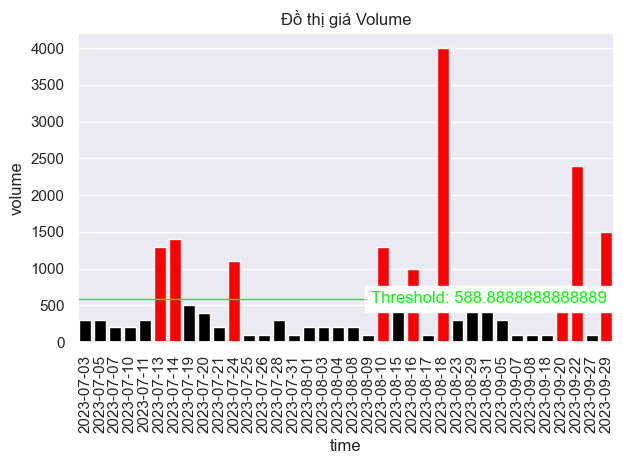

In [ ]:
ax = sns.barplot(data=WCS_df, x='time', y='volume', color='black') # tạo đồ thị với các cột vào đen theo trục x thuộc time và trục y thuộc volume
plt.xticks(rotation = 90) # quay các giá trị ngày góc 90 độ để dễ nhìn

for bar, value in zip(ax.patches, WCS_df['volume']):
    if value > threshold: # nếu các cột có giá trị cao hơn gái trị close trung bình 
        bar.set_facecolor('red') # các cột cao hơn sẽ được tô màu đỏ

plt.axhline(y=threshold, color='lime', linestyle='-', linewidth=1) # vẽ đường trung bình để ngăn cách giữa các giá trị cao hơn và thấp hơn nó

plt.text(x=len(WCS_df['time']) - 1, y=threshold, s=f'Threshold: {threshold}',  # chú thích giá trị trung bình lên đồ thị
         color='lime', va='center', ha='right', backgroundcolor='white')

plt.title('Đồ thị giá Volume') # đặt tên đồ thị
plt.tight_layout() 
plt.show()

# Câu 8

In [ ]:
print('Số lần giao dịch của cổ phiếu WCS: ', WCS_df.shape[0], # tính số lần giao dịch
    '\nGía close trung bình cổ phiếu WCS: ', int(WCS_df['close'].mean()), # tính giá close trung bình
    '\nGía close cao nhất cổ phiếu WCS: ', WCS_df['close'].max(), # tính giá close cao nhất
    '\nGía close thấp nhất cổ phiếu WCS: ', WCS_df['close'].min()) # tính giá close thấp nhất

Số lần giao dịch của cổ phiếu WCS:  36 
Gía close trung bình cổ phiếu WCS:  174619 
Gía close cao nhất cổ phiếu WCS:  180000 
Gía close thấp nhất cổ phiếu WCS:  162000


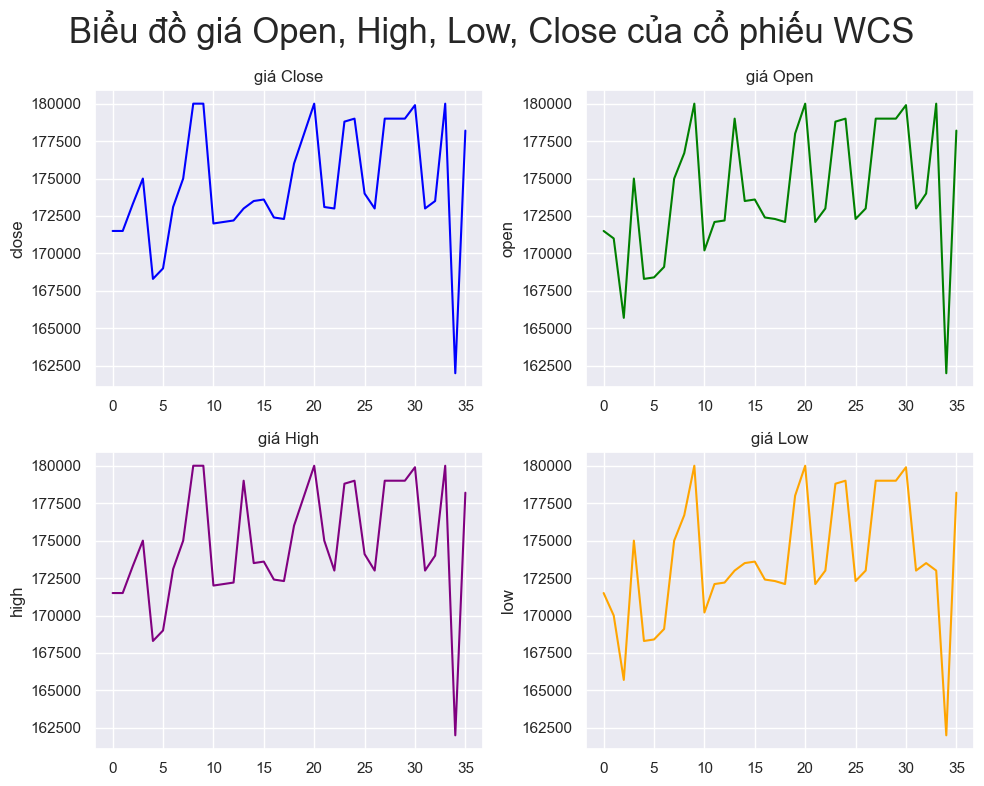

In [ ]:
fig, axes = plt.subplots(2, 2, figsize = (10, 8)) # tạo các đồ thị trống theo dạng ma trận

sns.lineplot(data = WCS_df['close'], ax = axes[0, 0], color = 'blue') # đồ thị đường giá close
axes[0, 0].set_title('giá Close')

sns.lineplot(data = WCS_df['open'], ax = axes[0, 1], color = 'green') # đồ thị đường giá open
axes[0, 1].set_title('giá Open')

sns.lineplot(data = WCS_df['high'], ax = axes[1, 0], color = 'purple') # đồ thị đường giá high
axes[1, 0].set_title('giá High')

sns.lineplot(data = WCS_df['low'], ax = axes[1, 1], color = 'orange') # đồ thị đường giá lơ
axes[1, 1].set_title('giá Low')

fig.suptitle("Biểu đồ giá Open, High, Low, Close của cổ phiếu WCS", fontsize = 25) # đặt tên chính cho đồ thị

plt.tight_layout()
plt.show()


# Câu 9

In [ ]:
X = WCS_df[['volume' ,'open', 'high', 'low']] # lựa ra các biến độc lập để tạo mô hình dự đoán
y = WCS_df['close'] # lựa ra biến close phụ thuộc để dữ đoán giá trị tương lai

model = LinearRegression() # tạo biến cho mô hình hồi quy tuyến tính
model.fit(X, y) # fit dữ liệu độc lập và phụ thuộc vào mô hình

In [ ]:
for coef, col in zip(model.coef_, X.columns):
    print('Hệ số hồi quy của', col, 'là', coef.round(3)) # in ra các hệ số tương ứng với các biến

Hệ số hồi quy của volume là 0.321
Hệ số hồi quy của open là -0.408
Hệ số hồi quy của high là 0.949
Hệ số hồi quy của low là 0.446


In [ ]:
equation = f"close = {model.intercept_:.3f} "
for coef, col in zip(model.coef_, X.columns):
    equation += f"+ ({coef:.3f} * {col}) " # tạo ra phương trình hồi quy 

print("Regression Equation:")
print(equation)


Regression Equation:
close = 2141.611 + (0.321 * volume) + (-0.408 * open) + (0.949 * high) + (0.446 * low) 


In [ ]:
r2 = model.score(X, y) # sử dụng hệ số r2 để đánh giá mô hình của tập train
print('Độ chính xác của mô hình trên tập dữ liệu lên đến', round(r2 * 100, 2),'%')

Độ chính xác của mô hình trên tập dữ liệu lên đến 96.05 %


In [ ]:
test_data = df_ticker.tail(5).reset_index().drop(columns = ['index']) # lấy 5 hàng của tháng 10 để test mô hình
X_test = test_data[['volume' ,'open', 'high', 'low']] # lấy ra các cột X tương ứng để dự đoán Y
y_test = test_data['close'] # lấy ra cột Y để dự đoán

In [ ]:
y_pred = model.predict(X_test) # dự đoán các giá trị Y mới theo tập dữ liệu 5 giá trị của tháng 10

In [ ]:
new_df = pd.DataFrame({'predicted value' : y_pred.round(0), 'actual value' : y_test}) # tạo dataframe để so sánh độ lệch giữa giá trị thật và giá trị dự đoán
new_df

,predicted value,actual value
0,180093.0,181000
1,169880.0,170000
2,186493.0,187000
3,173710.0,174000
4,179745.0,180000


In [ ]:
r2_new = r2_score(new_df['actual value'], new_df['predicted value']) # sử dụng hệ số r2 để đánh giá độ chính xác của giá trị dự đoán so với giá trị thật
print('Độ chính xác dự đoán dữ liệu tháng 10 lên đến', round(r2_new, 2),'%')

Độ chính xác dự đoán dữ liệu tháng 10 lên đến 0.99 %


# Câu 10

In [ ]:
X = WCS_df[['volume', 'open', 'high', 'low', 'close']] # lựa ra các cột để phân cụm ngày

In [ ]:
kmeans = KMeans(n_clusters = 3, random_state = 0) # tạo ra mô hình phân loại với 3 cụm ngẫu nhiên
kmeans.fit(X) # fit dữ liệu vào mô hình phân loại 
WCS_df['cluster'] = kmeans.predict(X) # phân các giá trị theo từng cụm cụ thể

In [ ]:
WCS_df['cluster'].value_counts().to_frame().reset_index() # tạo dataframe đếm các bao nhiêu ngày thuộc từng cụm tương ứng

,cluster,count
0,1,22
1,0,13
2,2,1


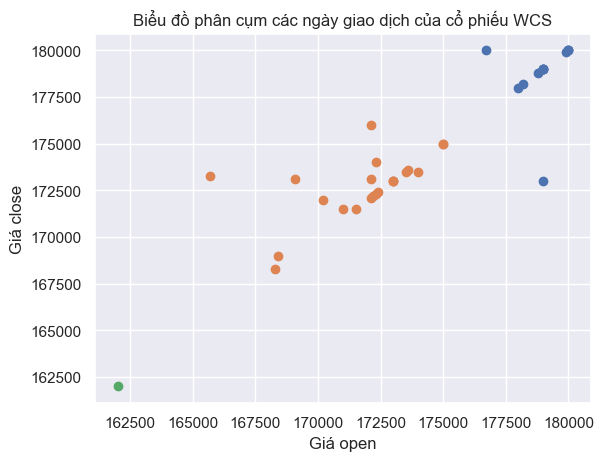

In [ ]:
for label in np.unique(kmeans.labels_):
    X_ = X[label == kmeans.labels_]
    plt.scatter(X_['open'], X_['close'], label = label) # vẽ đồ thị phân tán thể hiện các ngày nào thuộc cụm nào theo màu sắc tương ứng của từng cụm

plt.xlabel("Giá open")
plt.ylabel("Giá close")
plt.title("Biểu đồ phân cụm các ngày giao dịch của cổ phiếu WCS")
plt.show()